In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Etat de Référence / Variables

In [26]:
D0 = 0 # initial quantity of theobromine in the dog's body (mg/kg)
S0 = 0 # initial severity of symptoms
M_choc = np.array([10, 50, 100, 200, 500]) # initial mass of the chocolate ingested (g)
c_type = np.array([0.009, 1.85, 9.75]) # quantity of theobromine per gram of chocolate (mg/g) [chocolate blanc, chocolat au lait, chocolat noir]
choco_names = ['Chocolat blanc', 'Chocolat au lait', 'Chocolat noir']
W = np.array([15, 40, 60])  # weight of the dog (kg) [petit, moyen, grand]
k_abs = 0.25 # absorption rate constant (1/h) (au hasard pour l'instant)
k_e = 0.040 # elimination rate constant (1/h)
f = k_abs/(k_abs + k_e) # fraction of theobromine absorbed into the bloodstream
p = 0.4 # taux d'activation de symptômes (1/h)
K_D = np.array([20, 45, 60, 150]) # concentration of theobromine at which symptoms appear (mg/kg) (seuils de sévérité des symptômes) [léthargie, vomissements, convulsions, décès]
n = 4 # Hill coefficient
mu = 0.026 # taux de récupération (1/h)
Q0 = f*c_type[0]*M_choc[0] # initial amount of theobromine in the gastrointestinal compartment (mg)

## Modèle

In [15]:
def model(t, y, k_abs, k_e, W, p, K_D, n, mu):

    Q, D, S1, S2, S3, S4 = y

    dQdt = -k_abs * Q
    dDdt = (k_abs / W) * Q - k_e * D

    dS1 = p*(D**n/(K_D[0]**n + D**n))*(1-S1) - mu*S1
    dS2 = p*(D**n/(K_D[1]**n + D**n))*(1-S2) - mu*S2
    dS3 = p*(D**n/(K_D[2]**n + D**n))*(1-S3) - mu*S3
    dS4 = p*(D**n/(K_D[3]**n + D**n))*(1-S4) - mu*S4

    return [dQdt, dDdt, dS1, dS2, dS3, dS4]

## Simulation

In [29]:
def run_sim(M, c, W):
    Q0 = f * c * M
    y0 = [Q0, 0, 0, 0, 0, 0]
    sol = solve_ivp(model, (0, 48), y0, args=(k_abs, k_e, W, p, K_D, n, mu), t_eval=np.arange(0, 48, 2))
    return sol

## Visualisation

Graphe  Baseline dynamic

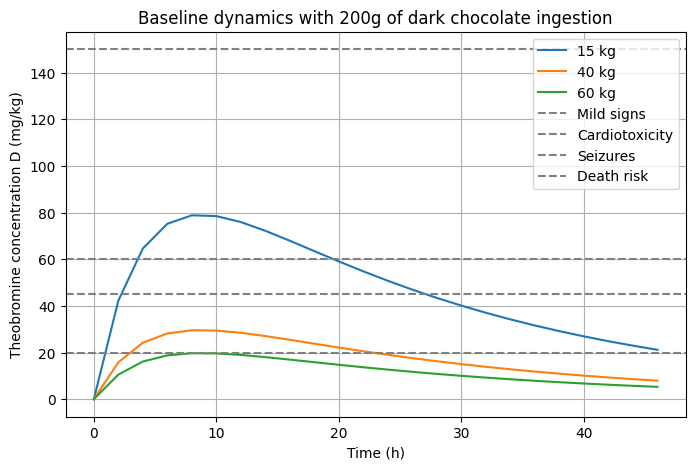

In [7]:
plt.figure(figsize=(8,5))

M_baseline = 200          # masse fixée
c_baseline = c_type[2]    # chocolat noir

for w in W:

    sol = run_sim(M_baseline, c_baseline, w)

    plt.plot(
        sol.t,
        sol.y[1],
        label=f"{w} kg"
    )

plt.axhline(20, ls='--', color='gray', label='Mild signs')
plt.axhline(45, ls='--', color='gray', label='Cardiotoxicity')
plt.axhline(60, ls='--', color='gray', label='Seizures')
plt.axhline(150, ls='--', color='gray', label='Death risk')

plt.xlabel("Time (h)")
plt.ylabel("Theobromine concentration D (mg/kg)")
plt.title("Baseline dynamics with 200g of dark chocolate ingestion")
plt.legend()
plt.grid()

plt.show()

Calculs des observables

In [23]:
threshold = 20  # seuil mild signs

for w in W:

    sol = run_sim(M_baseline, c_baseline, w)

    D = sol.y[1]

    Dmax = np.max(D)

    peak_idx = np.argmax(D)

    after_peak = np.where(D[peak_idx:] < threshold)[0]

    if len(after_peak) > 0:
        recovery_time = sol.t[peak_idx + after_peak[0]]
        print(f"{w} kg : recovery time = {recovery_time:.1f} h")
    else:
        print(f"{w} kg : not recovered within simulation time")
    
    print(f"{w} kg : Dmax = {Dmax:.1f} mg/kg")
    for i in range(2, 6):
        Smax = np.max(sol.y[i])
        print(f"{w} kg : S{i-1} max = {Smax:.2f}")

15 kg : not recovered within simulation time
15 kg : Dmax = 78.8 mg/kg
15 kg : S1 max = 0.94
15 kg : S2 max = 0.93
15 kg : S3 max = 0.90
15 kg : S4 max = 0.24
40 kg : recovery time = 24.0 h
40 kg : Dmax = 29.6 mg/kg
40 kg : S1 max = 0.91
40 kg : S2 max = 0.44
40 kg : S3 max = 0.19
40 kg : S4 max = 0.01
60 kg : recovery time = 8.0 h
60 kg : Dmax = 19.7 mg/kg
60 kg : S1 max = 0.81
60 kg : S2 max = 0.13
60 kg : S3 max = 0.04
60 kg : S4 max = 0.00


Effet de la quantité de chocolat ingérée

10 g : recovery time = 8.0 h
10 g : Dmax = 3.94 mg/kg
50 g : recovery time = 8.0 h
50 g : Dmax = 19.71 mg/kg
100 g : recovery time = 32.0 h
100 g : Dmax = 39.41 mg/kg
200 g : not recovered within simulation time
200 g : Dmax = 78.83 mg/kg
500 g : not recovered within simulation time
500 g : Dmax = 197.06 mg/kg


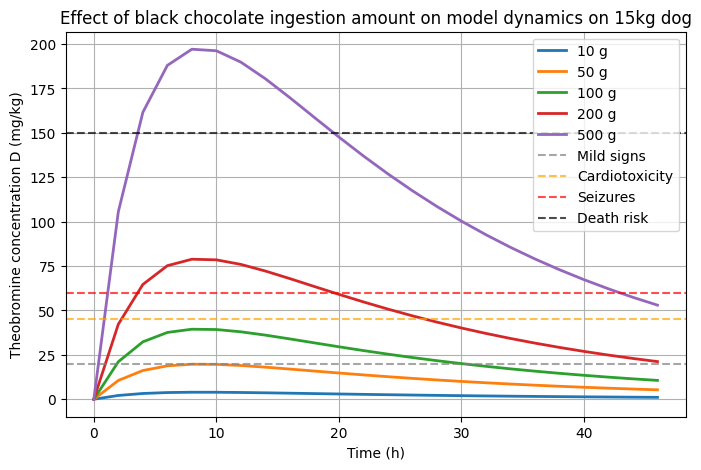

In [22]:
plt.figure(figsize=(8,5))

dog_weight = 15
chocolate_type = c_type[2]  # chocolat noir


for M in M_choc:

    sol = run_sim(M, chocolate_type, dog_weight)

    plt.plot(
        sol.t,
        sol.y[1],
        linewidth=2,
        label=f'{M} g')

    D = sol.y[1]

    Dmax = np.max(D)

    peak_idx = np.argmax(D)

    after_peak = np.where(D[peak_idx:] < threshold)[0]

    if len(after_peak) > 0:
        recovery_time = sol.t[peak_idx + after_peak[0]]
        print(f"{M} g : recovery time = {recovery_time:.1f} h")
    else:
        print(f"{M} g : not recovered within simulation time")
    
    print(f"{M} g : Dmax = {Dmax:.2f} mg/kg")
    

# seuils toxiques
plt.axhline(20, ls='--', color='gray', alpha=0.7, label='Mild signs')
plt.axhline(45, ls='--', color='orange', alpha=0.7, label='Cardiotoxicity')
plt.axhline(60, ls='--', color='red', alpha=0.7, label='Seizures')
plt.axhline(150, ls='--', color='black', alpha=0.7, label='Death risk')

plt.xlabel('Time (h)')
plt.ylabel('Theobromine concentration D (mg/kg)')
plt.title('Effect of black chocolate ingestion amount on model dynamics on 15kg dog')
plt.grid(True)
plt.legend()

plt.show()

Effet du type de chocolat ingéré

White chocolate : recovery time = 8.0 h
White chocolate kg : Dmax = 0.07 mg/kg
Milk chocolate : recovery time = 8.0 h
Milk chocolate kg : Dmax = 14.96 mg/kg
Dark chocolate kg : not recovered within simulation time
Dark chocolate kg : Dmax = 78.83 mg/kg


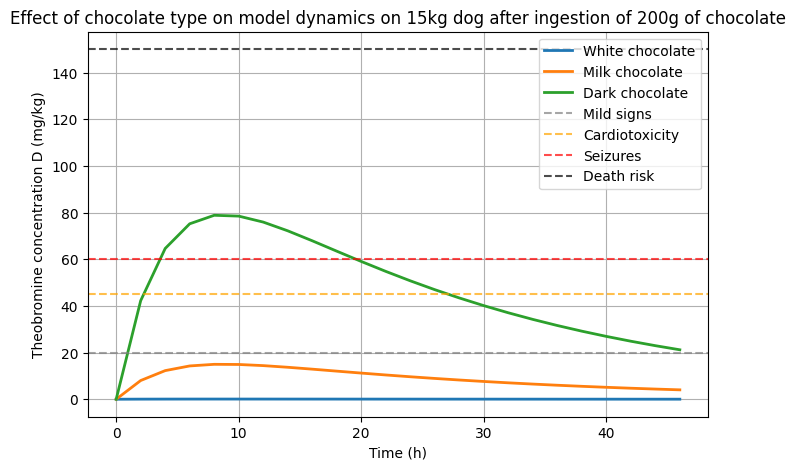

In [19]:
plt.figure(figsize=(8,5))

dog_weight = 15
M = 200

threshold = 20  # seuil mild signs

for c, name in zip(c_type, choco_names):

    sol = run_sim(M, c, dog_weight)

    plt.plot(
        sol.t,
        sol.y[1],
        linewidth=2,
        label=name)

    D = sol.y[1]

    Dmax = np.max(D)

    peak_idx = np.argmax(D)

    after_peak = np.where(D[peak_idx:] < threshold)[0]

    if len(after_peak) > 0:
        recovery_time = sol.t[peak_idx + after_peak[0]]
        print(f"{name} : recovery time = {recovery_time:.1f} h")
    else:
        print(f"{name} kg : not recovered within simulation time")
    
    print(f"{name} kg : Dmax = {Dmax:.2f} mg/kg")
    
    
# seuils toxiques
plt.axhline(20, ls='--', color='gray', alpha=0.7, label='Mild signs')
plt.axhline(45, ls='--', color='orange', alpha=0.7, label='Cardiotoxicity')
plt.axhline(60, ls='--', color='red', alpha=0.7, label='Seizures')
plt.axhline(150, ls='--', color='black', alpha=0.7, label='Death risk')

plt.xlabel('Time (h)')
plt.ylabel('Theobromine concentration D (mg/kg)')
plt.title('Effect of chocolate type on model dynamics on 15kg dog after ingestion of 200g of chocolate')
plt.grid(True)
plt.legend()

plt.show()

Graphe baseline dynamic des symptômes

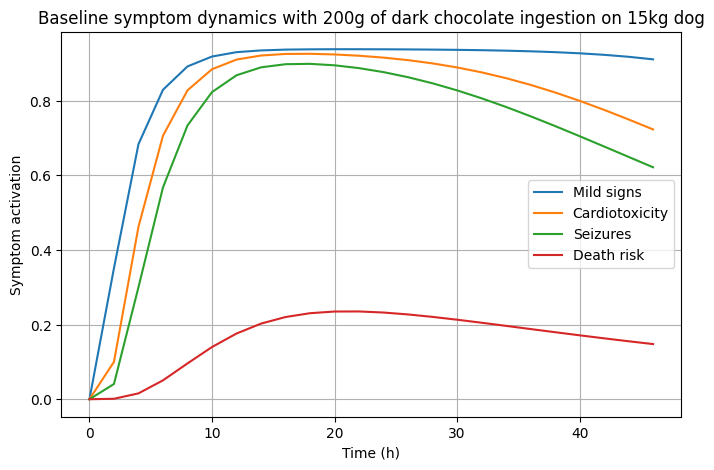

In [27]:
sol = run_sim(200, c_type[2], 15)

plt.figure(figsize=(8,5))

plt.plot(sol.t, sol.y[2], label='Mild signs')
plt.plot(sol.t, sol.y[3], label='Cardiotoxicity')
plt.plot(sol.t, sol.y[4], label='Seizures')
plt.plot(sol.t, sol.y[5], label='Death risk')

plt.xlabel('Time (h)')
plt.ylabel('Symptom activation')
plt.title('Baseline symptom dynamics with 200g of dark chocolate ingestion on 15kg dog')
plt.legend()
plt.grid()
plt.show()